Predict Number With MNIST Model Using LeNet-5

Source Dataset :
- MNIST : https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html
- Hand Writing Kaggle : https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9/data

In [1]:
import torch
import torchvision
from torch.utils.data import ConcatDataset, DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
from pathlib import Path

import kagglehub
import shutil
import torch

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split


def create_mnist_dataloaders(
    root: str,
    transform_mnist: transforms.Compose,
    transform_kaggle: transforms.Compose,
    batch_size: int,
    num_workers: int = 4,
):

    # MNIST Dataset
    mnist_train = datasets.MNIST(
        root=root,
        train=True,
        download=True,
        transform=transform_mnist,
    )

    mnist_test = datasets.MNIST(
        root=root,
        train=False,
        download=True,
        transform=transform_kaggle,
    )


    # Download Kaggle Dataset
    source_path = Path(
        kagglehub.dataset_download(
            "olafkrastovski/handwritten-digits-0-9"
        )
    )

    destination_path = Path(root) / "handwritten-digits-0-9"

    if not destination_path.exists():
        shutil.copytree(
            source_path,
            destination_path
        )


    # Kaggle Dataset
    full_custom_dataset = datasets.ImageFolder(
        root=destination_path,
        transform=transform_kaggle,
    )


    # Check Class Mapping
    print("Kaggle Class Mapping:")
    print(full_custom_dataset.class_to_idx)

    print("\nKaggle Classes:")
    print(full_custom_dataset.classes)


    img, label = full_custom_dataset[0]

    print("\nSample Kaggle:")
    print("Label index :", label)
    print("Class name  :", full_custom_dataset.classes[label])


    # Split Kaggle Dataset
    train_size = int(len(full_custom_dataset) * 0.8)
    test_size = len(full_custom_dataset) - train_size

    generator = torch.Generator().manual_seed(42)

    custom_train, custom_test = random_split(
        full_custom_dataset,
        [train_size, test_size],
        generator=generator,
    )


    # Combine Dataset
    train_dataset = ConcatDataset([
        mnist_train,
        custom_train
    ])

    test_dataset = ConcatDataset([
        mnist_test,
        custom_test
    ])


    # DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )


    # gunakan class dari dataset
    class_names = full_custom_dataset.classes


    print("\nDataset Size:")
    print("MNIST Train      :", len(mnist_train))
    print("Kaggle Train     :", len(custom_train))
    print("Total Train      :", len(train_dataset))

    print("MNIST Test       :", len(mnist_test))
    print("Kaggle Test      :", len(custom_test))
    print("Total Test       :", len(test_dataset))


    return (
        train_loader,
        test_loader,
        mnist_test,
        custom_test,
        class_names
    )

In [4]:
import torch
import torchvision
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import Dict, List, Tuple
from pathlib import Path
from PIL import Image, ImageOps


def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:

  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(y_pred, dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.dataloader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:

  model.eval()

  test_loss, test_acc = 0,0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device) -> Dict[str, List]:

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  train_start_time = timer()

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)

    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    print(f"epoch : {epoch + 1} | train_loss : {train_loss:.4f} | train_acc : {train_acc:.4f} | test_loss : {test_loss:.4f} | test_acc : {test_acc:.4f}\n")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  train_end_time = timer()

  print(f"Waktu Yang Dibutuhkan Training : {train_end_time - train_start_time:.3f} seconds")

  return results

def predict(model, image_path, device, transform=None):
    if device is None:
        device = next(model.parameters()).device

    image = Image.open(image_path).convert("RGB")

    if np.array(image.convert("L")).mean() > 127:
        image = ImageOps.invert(image)

    if transform is not None:
        image = transform(image)

    image = image.unsqueeze(0).to(device)
    model.to(device)
    model.eval()

    with torch.inference_mode():
        logits = model(image)
        probs = torch.softmax(logits, dim=1)

    pred = probs.argmax(dim=1).item()
    prob = probs.max().item()
    return pred, prob

In [5]:
# LeNet-5 Architecture Source : https://medium.com/codex/lenet-5-complete-architecture-84c6d08215f9

import torch
from torch import nn

class LeNet5(nn.Module):
  """
  LeNet-5 (Paper Style)

  Reference:
  LeCun et al. (1998)
  https://ieeexplore.ieee.org/document/726791
  """


  def __init__(self, num_classes:int = 10):
    super().__init__()

    self.features = nn.Sequential(
      # Convolution Layer 1
      nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5),
      nn.Tanh(),

      # Subsampling Layer 2
      nn.AvgPool2d(kernel_size=2, stride=2),

      # Convolution Layer 3
      nn.Conv2d(6, 16, kernel_size=5),
      nn.Tanh(),

      # Subsampling Layer 4
      nn.AvgPool2d(kernel_size=2, stride=2),

      # Convolution Layer 5
      nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5),
      nn.Tanh(),
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),

      # Fully Connected
      nn.Linear(120, 84),
      nn.Tanh(),

      # Output
      nn.Linear(84, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)

    return x

In [6]:
import torch
from pathlib import Path


def save_checkpoint(
    model: torch.nn.Module,
    model_path: str | Path,
    class_names: list[str],
):
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
    }

    torch.save(checkpoint, model_path)

    print(f"[INFO] Checkpoint saved to: {model_path}")

In [7]:
mnist_train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

kaggle_train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [8]:
train_loader, test_loader, mnist_test, custom_test, class_names = create_mnist_dataloaders(root="data",
                                                                                transform_mnist=mnist_train_transform,
                                                                                transform_kaggle=kaggle_train_transform,
                                                                                batch_size=32,
                                                                                num_workers=0)


100%|██████████| 9.91M/9.91M [00:00<00:00, 66.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


Using Colab cache for faster access to the 'handwritten-digits-0-9' dataset.
Kaggle Class Mapping:
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}

Kaggle Classes:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Sample Kaggle:
Label index : 0
Class name  : 0

Dataset Size:
MNIST Train      : 60000
Kaggle Train     : 17244
Total Train      : 77244
MNIST Test       : 10000
Kaggle Test      : 4311
Total Test       : 14311


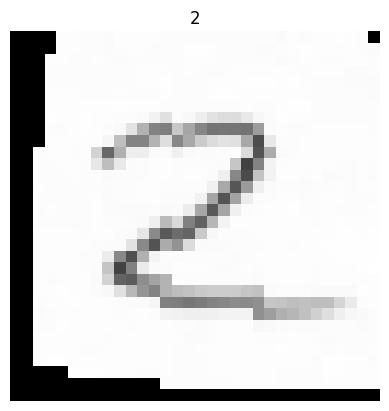

In [9]:
img, label = custom_test[0]

plt.imshow(img.squeeze() * 0.5 + 0.5, cmap="gray")
plt.title(label)
plt.axis("off")
plt.show()

In [10]:
def test_accuracy(model, dataset, device):
    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    model.eval()

    correct = 0
    total = 0

    with torch.inference_mode():
        for image, label in loader:
            image = image.to(device)
            label = label.to(device)

            logits = model(image)
            pred = logits.argmax(dim=1)

            correct += (pred == label).sum().item()
            total += label.size(0)

    return correct / total

In [11]:
model = LeNet5(num_classes=len(class_names)).to(device)
model

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=84, bias=True)
    (2): Tanh()
    (3): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [12]:
mnist_acc = test_accuracy(
    model,
    mnist_test,
    device
)

custom_acc = test_accuracy(
    model,
    custom_test,
    device
)

print(f"MNIST Accuracy      : {mnist_acc:.2%}")
print(f"Handwriting Accuracy: {custom_acc:.2%}")

MNIST Accuracy      : 10.85%
Handwriting Accuracy: 8.54%


In [13]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

In [14]:
results = train(model=model,
             train_dataloader=train_loader,
             test_dataloader=test_loader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             epochs=10,
             device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

epoch : 1 | train_loss : 0.6534 | train_acc : 0.7720 | test_loss : 0.8404 | test_acc : 0.7201

epoch : 2 | train_loss : 0.3415 | train_acc : 0.8895 | test_loss : 0.5389 | test_acc : 0.8329

epoch : 3 | train_loss : 0.2251 | train_acc : 0.9280 | test_loss : 0.4435 | test_acc : 0.8620

epoch : 4 | train_loss : 0.1772 | train_acc : 0.9439 | test_loss : 0.4514 | test_acc : 0.8646

epoch : 5 | train_loss : 0.1549 | train_acc : 0.9494 | test_loss : 0.4126 | test_acc : 0.8769

epoch : 6 | train_loss : 0.1383 | train_acc : 0.9556 | test_loss : 0.3727 | test_acc : 0.8886

epoch : 7 | train_loss : 0.1265 | train_acc : 0.9597 | test_loss : 0.3582 | test_acc : 0.8937

epoch : 8 | train_loss : 0.1165 | train_acc : 0.9630 | test_loss : 0.3418 | test_acc : 0.9030

epoch : 9 | train_loss : 0.1125 | train_acc : 0.9635 | test_loss : 0.3533 | test_acc : 0.8979

epoch : 10 | train_loss : 0.1039 | train_acc : 0.9665 | test_loss : 0.3684 | test_acc : 0.8964

Waktu Yang Dibutuhkan Training : 524.387 seconds


In [15]:
correct = 0
total = 0

model.eval()

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Correct : {correct}")
print(f"Total   : {total}")
print(f"Acc     : {correct/total:.4f}")

Correct : 12823
Total   : 14311
Acc     : 0.8960


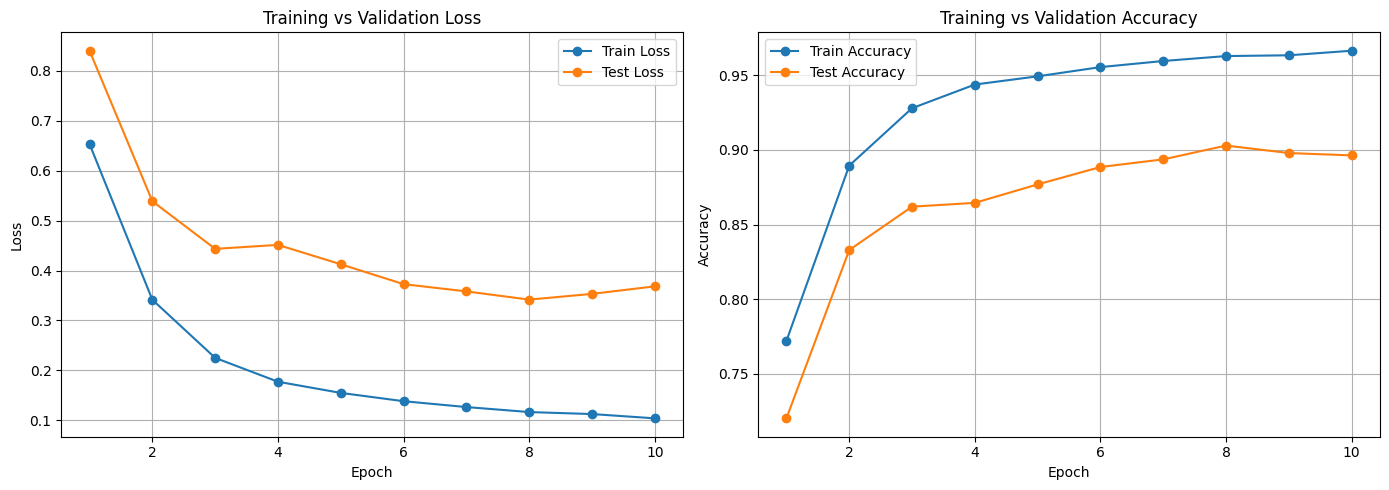

In [16]:
import matplotlib.pyplot as plt

train_loss = results["train_loss"]
test_loss = results["test_loss"]
train_acc = results["train_acc"]
test_acc = results["test_acc"]

epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(epochs, train_loss, label="Train Loss", marker="o")
ax[0].plot(epochs, test_loss, label="Test Loss", marker="o")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax[1].plot(epochs, test_acc, label="Test Accuracy", marker="o")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [17]:
save_checkpoint(model=model,
                           model_path="models/mnist_model_lenet5_trained_experiments.pth",
                           class_names=class_names)

[INFO] Checkpoint saved to: models/mnist_model_lenet5_trained_experiments.pth


In [18]:
mnist_acc = test_accuracy(
    model,
    mnist_test,
    device
)

custom_acc = test_accuracy(
    model,
    custom_test,
    device
)

print(f"MNIST Accuracy      : {mnist_acc:.2%}")
print(f"Handwriting Accuracy: {custom_acc:.2%}")

MNIST Accuracy      : 90.91%
Handwriting Accuracy: 86.59%


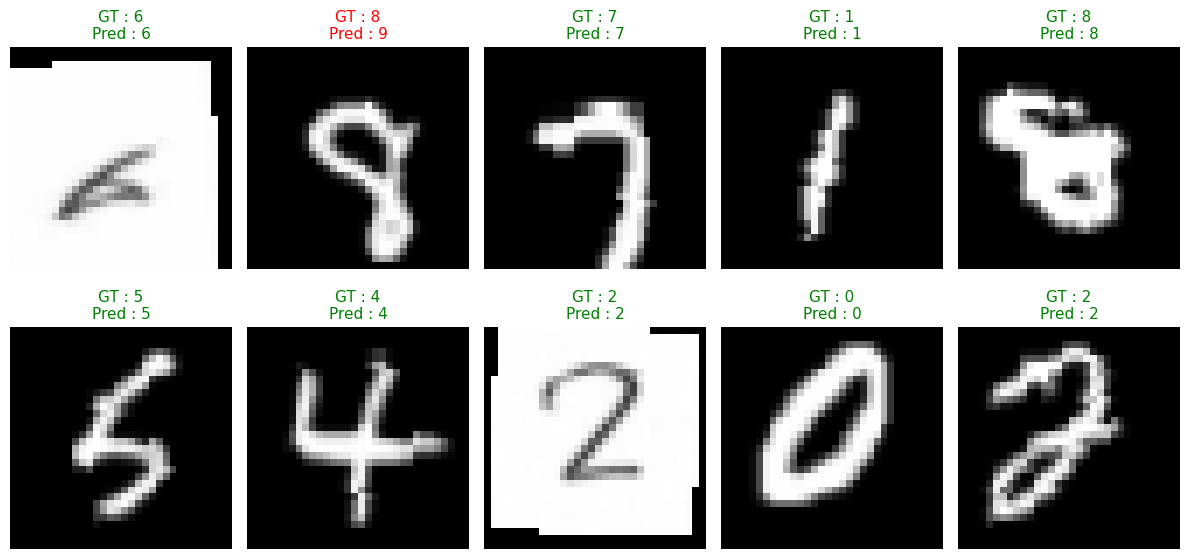

In [19]:
import random
import matplotlib.pyplot as plt

model.eval()

samples = []

with torch.inference_mode():
    for images, labels in test_loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1).cpu()

        for img, lbl, pred in zip(images, labels, preds):
            samples.append((img, lbl.item(), pred.item()))

# Ambil 10 sampel acak
random_samples = random.sample(samples, 10)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for ax, (img, lbl, pred) in zip(axes, random_samples):
    ax.imshow(img.squeeze() * 0.5 + 0.5, cmap="gray")

    color = "green" if lbl == pred else "red"

    ax.set_title(
        f"GT : {lbl}\nPred : {pred}",
        color=color,
        fontsize=11
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

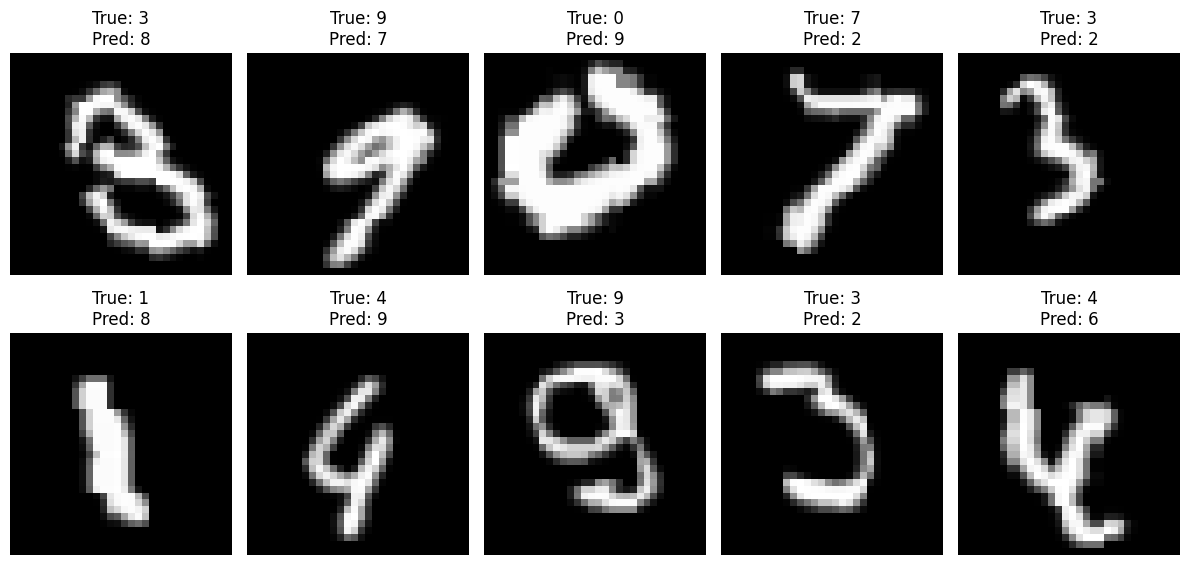

In [20]:
model.eval()

wrong_samples = []

with torch.inference_mode():
    for image, label in test_loader:
        logits = model(image.to(device))
        preds = logits.argmax(dim=1).cpu()

        for img, lbl, pred in zip(image, label, preds):
            if lbl != pred:
                wrong_samples.append((img, lbl, pred))

            if len(wrong_samples) == 10:
                break

        if len(wrong_samples) == 10:
            break


fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, (img, lbl, pred) in enumerate(wrong_samples):
    axes[i].imshow(img.squeeze() * 0.5 + 0.5, cmap="gray")
    axes[i].set_title(
        f"True: {lbl}\nPred: {pred}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

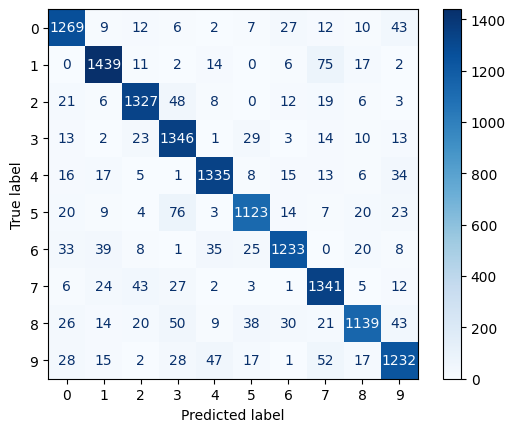

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

all_preds = []
all_labels = []

model.eval()

with torch.inference_mode():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.show()

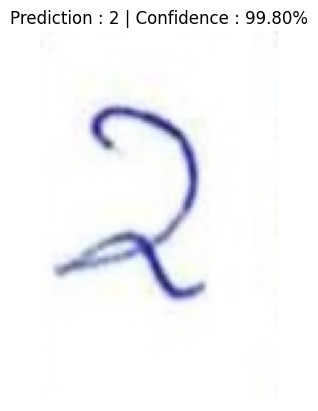

In [24]:
from PIL import Image

path_data = Path("data/")
image_path = path_data / "prediction_image/test_pred.jpg"

image = Image.open(image_path)

transforms_pred = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

pred, prob = predict(
    model=model,
    image_path=image_path,
    device=device,
    transform=transforms_pred,
)

plt.imshow(image)
plt.title(f"Prediction : {class_names[pred]} | Confidence : {prob:.2%}")
plt.axis("off")
plt.show()